# Atelectasis vs Effusion: ResNet50 + PCA with MLP & EfficientNet-B4

This notebook classifies chest X-ray images from the **NIH Chest X-Ray dataset** into 2 disease classes:
* **Atelectasis**
* **Effusion**

Only single-label images are used (multi-label rows are excluded). The notebook explores two feature extraction and classification approaches:

### Approach 1 - ResNet50 + PCA + MLP
A pretrained **ResNet50** (frozen, no fine-tuning) is used as a feature extractor to generate **2048-dimensional** feature vectors from each image. **PCA** is applied to reduce dimensionality from 2048 to **974 components** (retaining 95% variance). These reduced features are used to train an **MLP** (Dense neural network) with 3 hidden layers, batch normalization, and dropout.

### Approach 2 - EfficientNet-B4 Fine-Tuning
A pretrained **EfficientNet-B4** is fine-tuned directly on the raw chest X-ray images in two phases: first with a frozen base (training only the classification head), then unfreezing the top 30 layers for end-to-end fine-tuning with a lower learning rate.

Both models are compared using **classification report**, **confusion matrix**, and **ROC-AUC curves** in a final summary.

## Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import os, glob, cv2
import time
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score,
                             accuracy_score, precision_score, recall_score)

import tensorflow as tf
from tensorflow.keras.applications import ResNet50, EfficientNetB4
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import layers, models, callbacks

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120
RANDOM_SEED = 42
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

2026-04-06 20:47:24.077046: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775508444.298338      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775508444.359461      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775508444.875752      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775508444.875791      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775508444.875794      24 computation_placer.cc:177] computation placer alr

## Load Dataset

In [2]:
CSV_PATH = "/kaggle/input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv"
df = pd.read_csv(CSV_PATH)
print("Shape:", df.shape)
df.head(3)

Shape: (112120, 12)


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN


## Select Columns & Map Image Paths

In [3]:
df = df[[
    'Image Index', 'Finding Labels', 'Follow-up #',
    'Patient ID', 'Patient Age', 'Patient Gender', 'View Position'
]].copy()

df.columns = [
    'image_path', 'labels', 'followup_num',
    'patient_id', 'age', 'gender', 'view_position'
]

BASE_DIR = "/kaggle/input/datasets/organizations/nih-chest-xrays/data"
all_images = glob.glob(os.path.join(BASE_DIR, "images_*", "images", "*.png"))
path_dict = {os.path.basename(x): x for x in all_images}
df["image_path"] = df["image_path"].map(path_dict)
df.head(3)

,image_path,labels,followup_num,patient_id,age,gender,view_position
0,/kaggle/input/datasets/organizations/nih-chest...,Cardiomegaly,0,1,58,M,PA
1,/kaggle/input/datasets/organizations/nih-chest...,Cardiomegaly|Emphysema,1,1,58,M,PA
2,/kaggle/input/datasets/organizations/nih-chest...,Cardiomegaly|Effusion,2,1,58,M,PA


## Clean Age Column

In [4]:
print("Age stats before cleaning:")
print(df['age'].describe())

df = df[df['age'] <= 120].reset_index(drop=True)
print("Rows after age cleaning:", len(df))

Age stats before cleaning:
count    112120.000000
mean         46.901463
std          16.839923
min           1.000000
25%          35.000000
50%          49.000000
75%          59.000000
max         414.000000
Name: age, dtype: float64
Rows after age cleaning: 112104


## Filter Single-Label Rows

In [5]:
multi_mask = df["labels"].str.contains("\\|")
print(f"Multi-label rows : {multi_mask.sum():,}")
print(f"Single-label rows: {(~multi_mask).sum():,}")

df = df[~multi_mask].copy().reset_index(drop=True)
print(f"\nWorking dataframe shape: {df.shape}")

Multi-label rows : 20,792
Single-label rows: 91,312

Working dataframe shape: (91312, 7)


## Balance Classes (Atelectasis vs Effusion)

In [6]:
df_balanced = pd.concat([
    df[df["labels"] == "Atelectasis"],
    df[df["labels"] == "Effusion"]
]).reset_index(drop=True)

df_balanced = df_balanced.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

print(df_balanced["labels"].value_counts())
print(f"Final shape: {df_balanced.shape}")

labels
Atelectasis    4214
Effusion       3955
Name: count, dtype: int64
Final shape: (8169, 7)


## Extract CNN Features (ResNet50)

In [7]:
base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')
print(f"ResNet50 loaded — output feature size: {base_model.output_shape[1]}")

def extract_cnn_features(image_path):
    img = cv2.imread(image_path)
    img = cv2.resize(img, (224, 224))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)
    features = base_model.predict(img, verbose=0)
    return features.flatten()

print("Extracting CNN features...")
start = time.time()

cnn_features = []
valid_indices = []

for idx, row in tqdm(df_balanced.iterrows(), total=len(df_balanced)):
    try:
        feat = extract_cnn_features(row["image_path"])
        cnn_features.append(feat)
        valid_indices.append(idx)
    except Exception as e:
        print(f"Error at index {idx}: {e}")

X = np.array(cnn_features)
y = df_balanced.loc[valid_indices, "labels"].values
print(f"\nDone in {(time.time()-start)/60:.1f} min")
print(f"Feature matrix shape: {X.shape}")
print(f"Labels shape: {y.shape}")

I0000 00:00:1775508473.131567      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775508473.137752      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
ResNet50 loaded — output feature size: 2048
Extracting CNN features...


  0%|          | 0/8169 [00:00<?, ?it/s]WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
I0000 00:00:1775508480.984371      71 service.cc:152] XLA service 0x7ab0e0003590 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775508480.984406      71 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775508480.984410      71 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775508481.830077      71 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1775508484.673574      71 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
100%|██████████| 8169/8169 [16:13<00:00,  8.39it/s]


Done in 16.2 min
Feature matrix shape: (8169, 2048)
Labels shape: (8169,)


## Encode Labels & Train-Test Split

In [8]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Classes:", le.classes_)
print("Encoded distribution:", np.bincount(y_encoded))

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y_encoded
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Classes: ['Atelectasis' 'Effusion']
Encoded distribution: [4214 3955]
Train: (6535, 2048), Test: (1634, 2048)


## Feature Scaling

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaling complete!")

Scaling complete!


## PCA - Variance & POV Explained

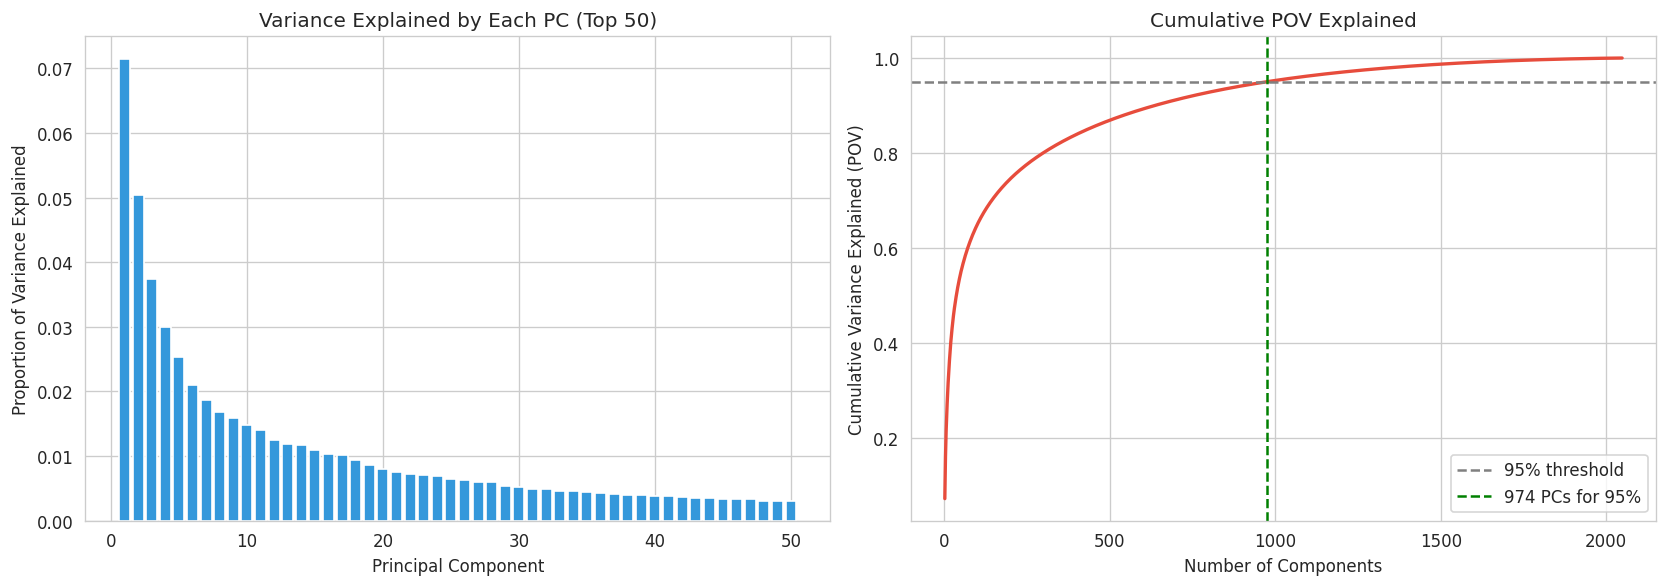

Components needed for 95% variance: 974


In [10]:
pca_full = PCA(random_state=RANDOM_SEED)
pca_full.fit(X_train_scaled)

cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, 51), pca_full.explained_variance_ratio_[:50], color='#3498db')
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Proportion of Variance Explained")
axes[0].set_title("Variance Explained by Each PC (Top 50)")

axes[1].plot(range(1, len(cumulative_var) + 1), cumulative_var, color='#e74c3c', lw=2)
axes[1].axhline(y=0.95, color='gray', linestyle='--', label='95% threshold')
n95 = np.argmax(cumulative_var >= 0.95) + 1
axes[1].axvline(x=n95, color='green', linestyle='--', label=f'{n95} PCs for 95%')
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Variance Explained (POV)")
axes[1].set_title("Cumulative POV Explained")
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"Components needed for 95% variance: {n95}")

## PCA - 2D Feature Visualization

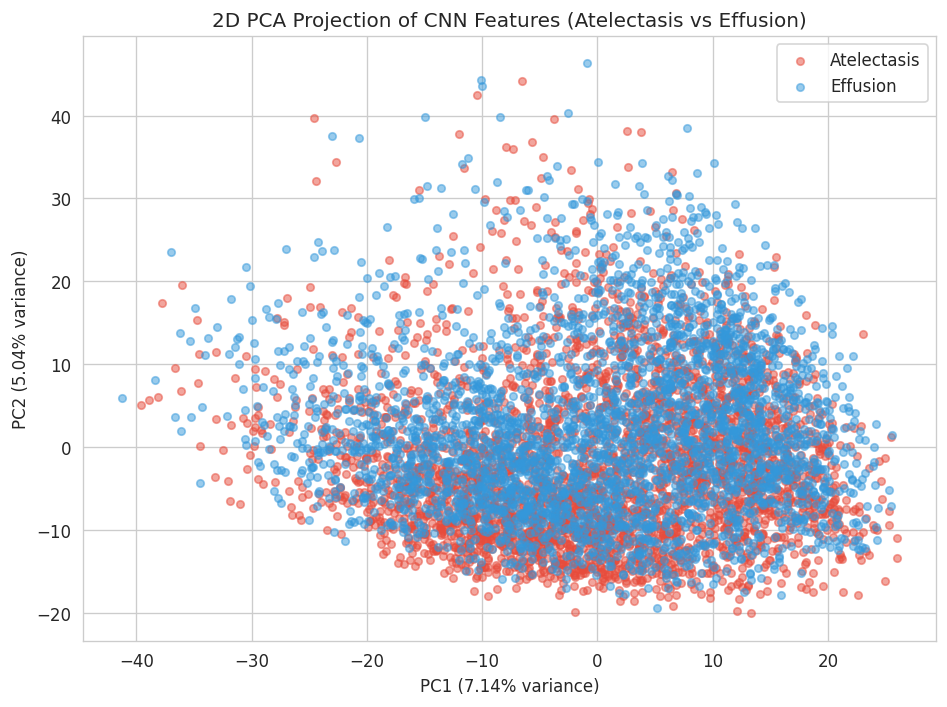

PC1 variance: 0.0714
PC2 variance: 0.0504
Total (2 PCs): 0.1218


In [11]:
pca_2d = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca_2d = pca_2d.fit_transform(X_train_scaled)

plt.figure(figsize=(8, 6))
for label, color in zip([0, 1], ['#e74c3c', '#3498db']):
    mask = y_train == label
    plt.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                c=color, label=le.classes_[label], alpha=0.5, s=20)

plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]:.2%} variance)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]:.2%} variance)")
plt.title("2D PCA Projection of CNN Features (Atelectasis vs Effusion)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"PC1 variance: {pca_2d.explained_variance_ratio_[0]:.4f}")
print(f"PC2 variance: {pca_2d.explained_variance_ratio_[1]:.4f}")
print(f"Total (2 PCs): {sum(pca_2d.explained_variance_ratio_):.4f}")

## Apply PCA (974 Components)

In [12]:
pca = PCA(n_components=974, random_state=RANDOM_SEED)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Original features:  {X_train_scaled.shape[1]}")
print(f"PCA features:       {X_train_pca.shape[1]}")
print(f"Variance retained:  {sum(pca.explained_variance_ratio_):.4f}")

Original features:  2048
PCA features:       974
Variance retained:  0.9489


## Build MLP Model

In [13]:
mlp_model = models.Sequential([
    layers.Input(shape=(974,)),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

mlp_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

mlp_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       124,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,633 (522.00 KB)

 Trainable params: 133,377 (521.00 KB)

 Non-trainable params: 256 (1.00 KB)

## Train MLP on PCA Features

In [14]:
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

print("Training MLP on PCA features...")
start = time.time()

mlp_history = mlp_model.fit(
    X_train_pca, y_train,
    validation_split=0.15,
    epochs=50,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print(f"\nDone in {(time.time()-start):.1f} sec")

Training MLP on PCA features...
Epoch 1/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.5226 - loss: 0.9991 - val_accuracy: 0.6707 - val_loss: 0.6212 - learning_rate: 5.0000e-04
Epoch 2/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6030 - loss: 0.7808 - val_accuracy: 0.6911 - val_loss: 0.5945 - learning_rate: 5.0000e-04
Epoch 3/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6528 - loss: 0.6850 - val_accuracy: 0.7054 - val_loss: 0.5845 - learning_rate: 5.0000e-04
Epoch 4/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6767 - loss: 0.6327 - val_accuracy: 0.7074 - val_loss: 0.5803 - learning_rate: 5.0000e-04
Epoch 5/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7119 - loss: 0.5769 - val_accuracy: 0.7187 - val_loss: 0.5753 - learning_rate: 5.0000e-04
Epoch 6/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7275 - loss: 0.5435 - val_accuracy: 0.7166 - val_loss: 0.5711 - learning_rate: 5.0000e-04
Epoch 7/50
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4m

## MLP Training Curves

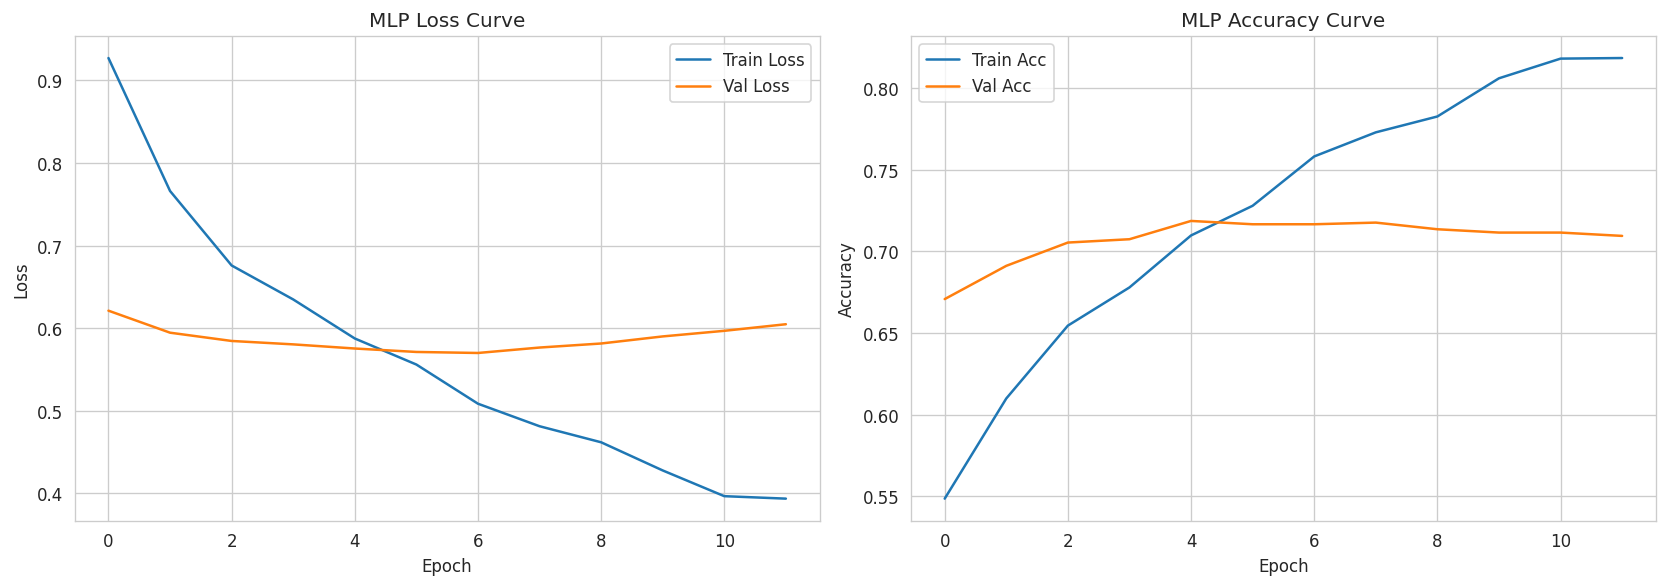

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(mlp_history.history['loss'], label='Train Loss')
axes[0].plot(mlp_history.history['val_loss'], label='Val Loss')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("MLP Loss Curve")
axes[0].legend()

axes[1].plot(mlp_history.history['accuracy'], label='Train Acc')
axes[1].plot(mlp_history.history['val_accuracy'], label='Val Acc')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("MLP Accuracy Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

## MLP Evaluation

In [16]:
y_scores_mlp = mlp_model.predict(X_test_pca).flatten()
y_pred_mlp = (y_scores_mlp >= 0.5).astype(int)

print("--- MLP Results (PCA features) ---")
print(classification_report(y_test, y_pred_mlp, target_names=le.classes_))
print(f"AUC: {roc_auc_score(y_test, y_scores_mlp):.4f}")

52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
--- MLP Results (PCA features) ---
              precision    recall  f1-score   support

 Atelectasis       0.71      0.71      0.71       843
    Effusion       0.69      0.70      0.69       791

    accuracy                           0.70      1634
   macro avg       0.70      0.70      0.70      1634
weighted avg       0.70      0.70      0.70      1634

AUC: 0.7866


## Prepare Image Paths & Labels for EfficientNet-B4

In [17]:
df_eff = df_balanced.loc[valid_indices].copy().reset_index(drop=True)
df_eff["label_encoded"] = le.transform(df_eff["labels"].values)

train_df, test_df = train_test_split(
    df_eff,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=df_eff["label_encoded"]
)
train_df, val_df = train_test_split(
    train_df,
    test_size=0.15,
    random_state=RANDOM_SEED,
    stratify=train_df["label_encoded"]
)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Train: 5554, Val: 981, Test: 1634


## Build Image Data Generators

In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 380

train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input
)

train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col="image_path", y_col="labels",
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=16,
    class_mode="binary", classes=list(le.classes_),
    shuffle=True, seed=RANDOM_SEED
)

val_gen = val_test_datagen.flow_from_dataframe(
    val_df, x_col="image_path", y_col="labels",
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=16,
    class_mode="binary", classes=list(le.classes_),
    shuffle=False
)

test_gen = val_test_datagen.flow_from_dataframe(
    test_df, x_col="image_path", y_col="labels",
    target_size=(IMG_SIZE, IMG_SIZE), batch_size=16,
    class_mode="binary", classes=list(le.classes_),
    shuffle=False
)

Found 5554 validated image filenames belonging to 2 classes.
Found 981 validated image filenames belonging to 2 classes.
Found 1634 validated image filenames belonging to 2 classes.


## Build EfficientNet-B4 Model

In [19]:
eff_base = EfficientNetB4(weights='imagenet', include_top=False,
                          input_shape=(IMG_SIZE, IMG_SIZE, 3))
eff_base.trainable = False

eff_model = models.Sequential([
    eff_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
])

eff_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

eff_model.summary()

71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb4 (Functional)     │ (None, 12, 12, 1792)   │    17,673,823 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1792)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       459,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,134,112 (69.18 MB)

 Trainable params: 459,777 (1.75 MB)

 Non-trainable params: 17,674,335 (67.42 MB)

## Train EfficientNet-B4 (Frozen Base)

In [20]:
early_stop_eff = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr_eff = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

print("Training EfficientNet-B4 (frozen base)...")
start = time.time()

eff_history_frozen = eff_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=[early_stop_eff, reduce_lr_eff],
    verbose=1
)

print(f"\nDone in {(time.time()-start)/60:.1f} min")

Training EfficientNet-B4 (frozen base)...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15


2026-04-06 21:05:42.537272: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 21:05:42.683223: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 21:05:42.962247: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 21:05:43.110047: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 21:05:43.490908: E external/local_xla/xla/stream_

263/348 ━━━━━━━━━━━━━━━━━━━━ 58s 684ms/step - accuracy: 0.5985 - loss: 0.8319

2026-04-06 21:09:12.988460: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 21:09:13.122227: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 21:09:13.349029: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 21:09:13.482901: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 21:09:13.720178: E external/local_xla/xla/stream_

348/348 ━━━━━━━━━━━━━━━━━━━━ 0s 762ms/step - accuracy: 0.6052 - loss: 0.8058

2026-04-06 21:11:04.191155: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 21:11:04.326908: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 21:11:04.559387: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 21:11:04.696304: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 21:11:04.945598: E external/local_xla/xla/stream_

348/348 ━━━━━━━━━━━━━━━━━━━━ 368s 900ms/step - accuracy: 0.6053 - loss: 0.8056 - val_accuracy: 0.5647 - val_loss: 0.9070 - learning_rate: 0.0010
Epoch 2/15
348/348 ━━━━━━━━━━━━━━━━━━━━ 255s 733ms/step - accuracy: 0.6610 - loss: 0.6247 - val_accuracy: 0.7044 - val_loss: 0.5796 - learning_rate: 0.0010
Epoch 3/15
348/348 ━━━━━━━━━━━━━━━━━━━━ 252s 725ms/step - accuracy: 0.6798 - loss: 0.5981 - val_accuracy: 0.6718 - val_loss: 0.6117 - learning_rate: 0.0010
Epoch 4/15
348/348 ━━━━━━━━━━━━━━━━━━━━ 252s 723ms/step - accuracy: 0.6830 - loss: 0.5921 - val_accuracy: 0.7197 - val_loss: 0.5544 - learning_rate: 0.0010
Epoch 5/15
348/348 ━━━━━━━━━━━━━━━━━━━━ 254s 728ms/step - accuracy: 0.6958 - loss: 0.5800 - val_accuracy: 0.7268 - val_loss: 0.5537 - learning_rate: 0.0010
Epoch 6/15
348/348 ━━━━━━━━━━━━━━━━━━━━ 250s 719ms/step - accuracy: 0.6877 - loss: 0.5976 - val_accuracy: 0.7248 - val_loss: 0.5496 - learning_rate: 0.0010
Epoch 7/15
348/348 ━━━━━━━━━━━━━━━━━━━━ 248s 712ms/step - accuracy: 0.6882 

## Fine-Tune EfficientNet-B4 (Unfreeze Top Layers)

In [21]:
eff_base.trainable = True

for layer in eff_base.layers[:-30]:
    layer.trainable = False

print(f"Trainable layers: {sum(1 for l in eff_model.layers if l.trainable)}")

eff_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Fine-tuning EfficientNet-B4...")
start = time.time()

eff_history_finetune = eff_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=[early_stop_eff, reduce_lr_eff],
    verbose=1
)

print(f"\nDone in {(time.time()-start)/60:.1f} min")

Trainable layers: 6
Fine-tuning EfficientNet-B4...
Epoch 1/15


2026-04-06 22:10:14.767972: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 22:10:14.920622: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 22:10:15.407781: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 22:10:15.548176: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 22:10:15.860115: E external/local_xla/xla/stream_

304/348 ━━━━━━━━━━━━━━━━━━━━ 29s 664ms/step - accuracy: 0.6480 - loss: 0.7009

2026-04-06 22:14:03.942495: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 22:14:04.094867: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 22:14:04.444088: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 22:14:04.626222: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


348/348 ━━━━━━━━━━━━━━━━━━━━ 347s 846ms/step - accuracy: 0.6483 - loss: 0.6979 - val_accuracy: 0.7156 - val_loss: 0.5758 - learning_rate: 1.0000e-05
Epoch 2/15
348/348 ━━━━━━━━━━━━━━━━━━━━ 252s 724ms/step - accuracy: 0.6750 - loss: 0.6270 - val_accuracy: 0.7187 - val_loss: 0.5677 - learning_rate: 1.0000e-05
Epoch 3/15
348/348 ━━━━━━━━━━━━━━━━━━━━ 251s 721ms/step - accuracy: 0.6884 - loss: 0.5949 - val_accuracy: 0.7278 - val_loss: 0.5618 - learning_rate: 1.0000e-05
Epoch 4/15
348/348 ━━━━━━━━━━━━━━━━━━━━ 249s 716ms/step - accuracy: 0.6979 - loss: 0.5931 - val_accuracy: 0.7248 - val_loss: 0.5480 - learning_rate: 1.0000e-05
Epoch 5/15
348/348 ━━━━━━━━━━━━━━━━━━━━ 250s 717ms/step - accuracy: 0.7261 - loss: 0.5629 - val_accuracy: 0.7339 - val_loss: 0.5453 - learning_rate: 1.0000e-05
Epoch 6/15
348/348 ━━━━━━━━━━━━━━━━━━━━ 256s 734ms/step - accuracy: 0.7261 - loss: 0.5454 - val_accuracy: 0.7452 - val_loss: 0.5358 - learning_rate: 1.0000e-05
Epoch 7/15
348/348 ━━━━━━━━━━━━━━━━━━━━ 251s 722ms/

## EfficientNet-B4 Training Curves

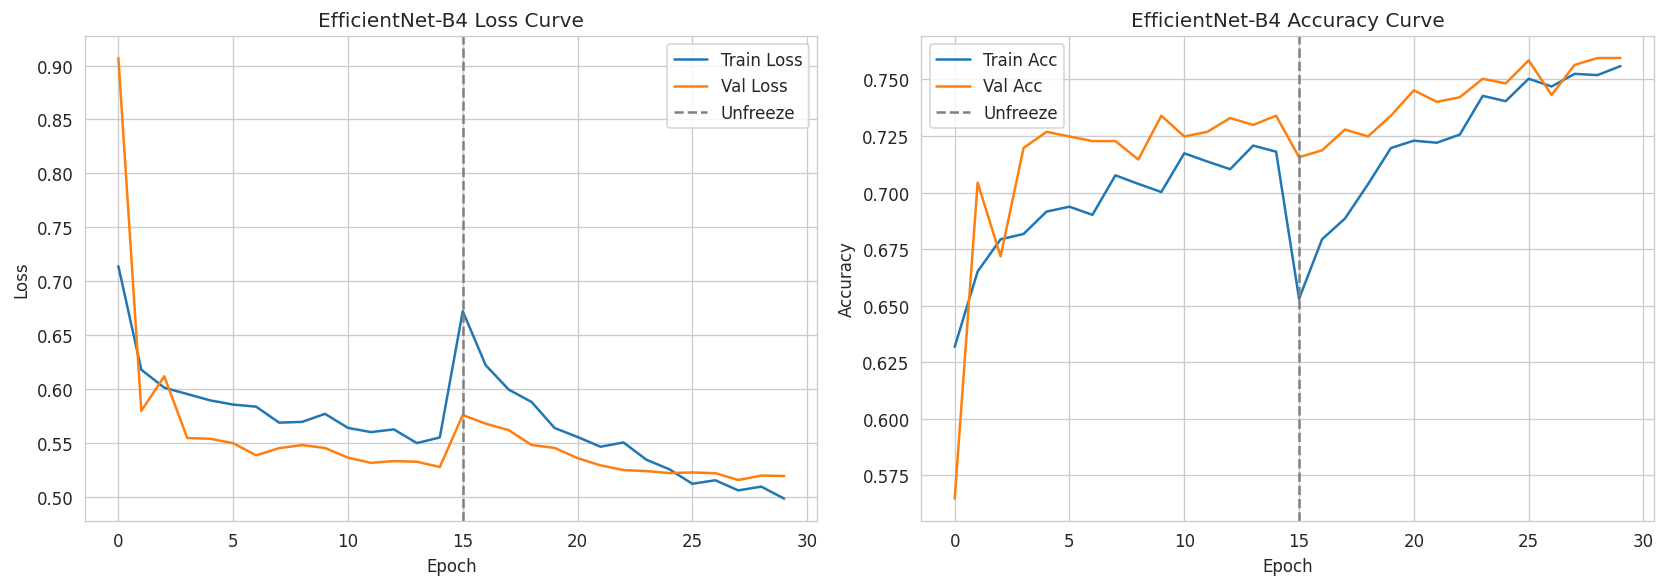

In [22]:
loss = eff_history_frozen.history['loss'] + eff_history_finetune.history['loss']
val_loss = eff_history_frozen.history['val_loss'] + eff_history_finetune.history['val_loss']
acc = eff_history_frozen.history['accuracy'] + eff_history_finetune.history['accuracy']
val_acc = eff_history_frozen.history['val_accuracy'] + eff_history_finetune.history['val_accuracy']
freeze_epochs = len(eff_history_frozen.history['loss'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(loss, label='Train Loss')
axes[0].plot(val_loss, label='Val Loss')
axes[0].axvline(x=freeze_epochs, color='gray', linestyle='--', label='Unfreeze')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("EfficientNet-B4 Loss Curve")
axes[0].legend()

axes[1].plot(acc, label='Train Acc')
axes[1].plot(val_acc, label='Val Acc')
axes[1].axvline(x=freeze_epochs, color='gray', linestyle='--', label='Unfreeze')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("EfficientNet-B4 Accuracy Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

## EfficientNet-B4 Evaluation

In [23]:
test_gen.reset()
y_scores_eff = eff_model.predict(test_gen).flatten()
y_test_eff = test_gen.classes
y_pred_eff = (y_scores_eff >= 0.5).astype(int)

print("--- EfficientNet-B4 Results ---")
print(classification_report(y_test_eff, y_pred_eff, target_names=le.classes_))
print(f"AUC: {roc_auc_score(y_test_eff, y_scores_eff):.4f}")

103/103 ━━━━━━━━━━━━━━━━━━━━ 54s 397ms/step
--- EfficientNet-B4 Results ---
              precision    recall  f1-score   support

 Atelectasis       0.74      0.76      0.75       843
    Effusion       0.73      0.72      0.73       791

    accuracy                           0.74      1634
   macro avg       0.74      0.74      0.74      1634
weighted avg       0.74      0.74      0.74      1634

AUC: 0.8115


##  Confusion Matrices - Both Models

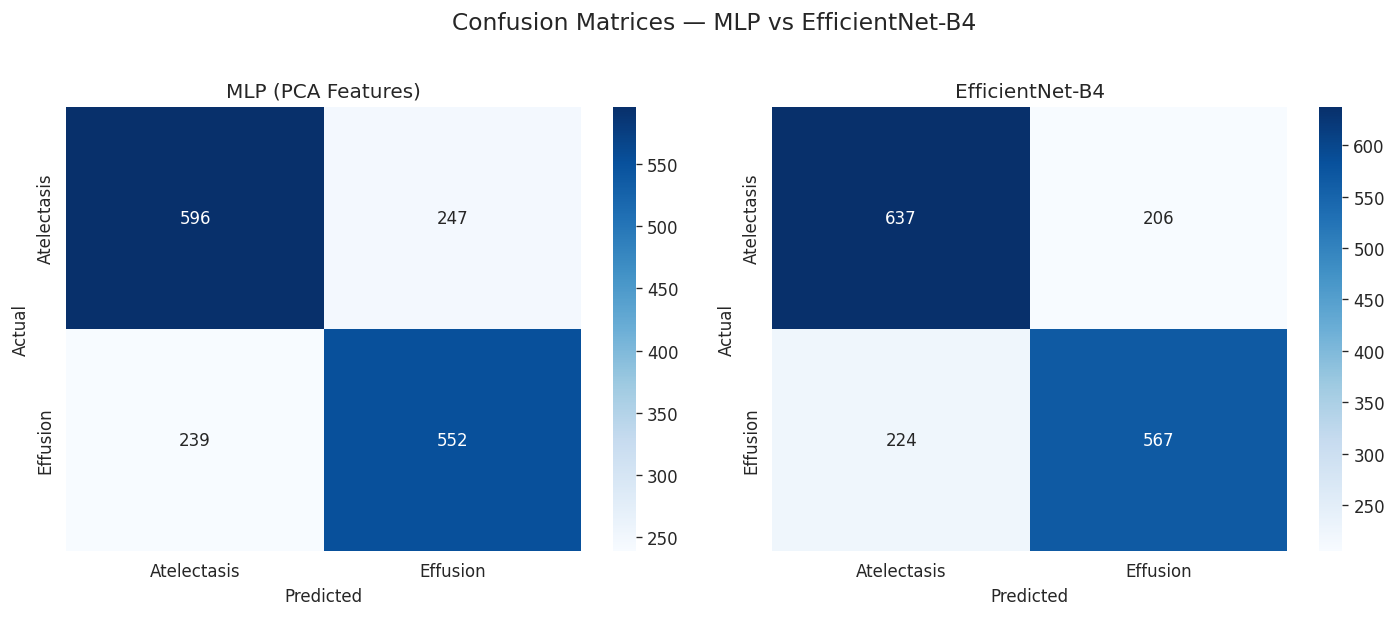

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_true, y_pred, title in zip(axes,
    [y_test, y_test_eff],
    [y_pred_mlp, y_pred_eff],
    ["MLP (PCA Features)", "EfficientNet-B4"]):

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title)

plt.suptitle("Confusion Matrices — MLP vs EfficientNet-B4", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## ROC Curves - Both Models

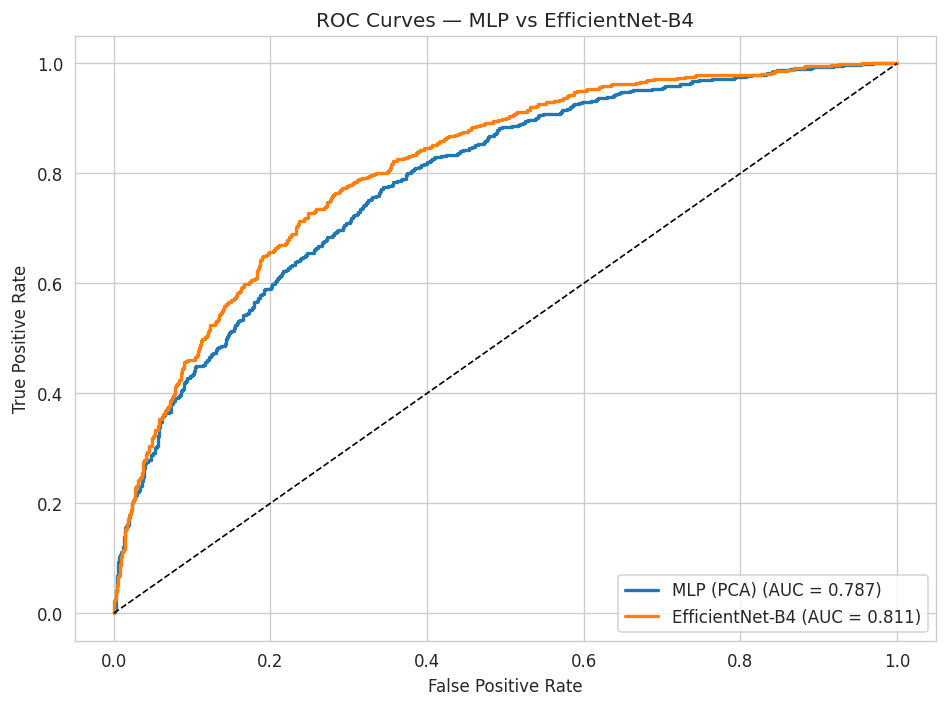

In [25]:
plt.figure(figsize=(8, 6))

for name, y_true, y_scores in [
    ("MLP (PCA)", y_test, y_scores_mlp),
    ("EfficientNet-B4", y_test_eff, y_scores_eff)
]:
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    auc = roc_auc_score(y_true, y_scores)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — MLP vs EfficientNet-B4")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Overall Metrics - Both Models

In [26]:
results = []

for name, y_true, y_pred, y_scores in [
    ("MLP (PCA)", y_test, y_pred_mlp, y_scores_mlp),
    ("EfficientNet-B4", y_test_eff, y_pred_eff, y_scores_eff)
]:
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (macro)": precision_score(y_true, y_pred, average='macro'),
        "Recall (macro)": recall_score(y_true, y_pred, average='macro'),
        "F1 (macro)": f1_score(y_true, y_pred, average='macro'),
        "AUC": roc_auc_score(y_true, y_scores)
    })

results_df = pd.DataFrame(results).set_index("Model")
results_df = results_df.round(4)
print("=" * 70)
print("          Overall Metrics — MLP vs EfficientNet-B4")
print("=" * 70)
print(results_df.to_string())

          Overall Metrics — MLP vs EfficientNet-B4
                 Accuracy  Precision (macro)  Recall (macro)  F1 (macro)     AUC
Model                                                                           
MLP (PCA)          0.7026             0.7023          0.7024      0.7024  0.7866
EfficientNet-B4    0.7368             0.7367          0.7362      0.7364  0.8115
